<a href="https://colab.research.google.com/github/pateldishant160-cmd/northstar/blob/main/Notebook2_Python_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#  Install and import libraries

!pip install pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['figure.dpi']    = 120

print('✅ Libraries ready!')

✅ Libraries ready!


In [ ]:

#  Load all NorthStar CSV datasets

customers  = pd.read_csv('customers.csv')
orders     = pd.read_csv('orders.csv')
deliveries = pd.read_csv('deliveries.csv')
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv')
hubs       = pd.read_csv('hubs.csv')
incidents  = pd.read_csv('incidents.csv')
complaints = pd.read_csv('complaints.csv')
app_events = pd.read_csv('app_events.csv')

datasets = {
    'customers': customers, 'orders': orders, 'deliveries': deliveries,
    'drivers': drivers, 'vehicles': vehicles, 'hubs': hubs,
    'incidents': incidents, 'complaints': complaints, 'app_events': app_events
}

print('📂 Datasets loaded:')
for name, df in datasets.items():
    print(f'   {name:12s}: {len(df):>5} rows × {len(df.columns):>2} columns')

📂 Datasets loaded:
   customers   :   650 rows ×  9 columns
   orders      :  1250 rows × 11 columns
   deliveries  :   950 rows × 13 columns
   drivers     :   170 rows ×  8 columns
   vehicles    :   120 rows ×  8 columns
   hubs        :     8 rows ×  5 columns
   incidents   :   280 rows ×  7 columns
   complaints  :   320 rows × 10 columns
   app_events  :   640 rows × 10 columns


In [ ]:

#  Missing value audit — find all NaN across all files

print('=== MISSING VALUE AUDIT ===')
print(f'{"Dataset":<15} {"Missing Cells":<15} {"Affected Columns"}')
print('-' * 65)

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        cols = ', '.join([f'{c}({n})' for c, n in missing.items()])
        print(f'{name:<15} {missing.sum():<15} {cols}')

print()
print('=== ZONE INCONSISTENCIES in customers.home_zone ===')
print(customers['home_zone'].value_counts().to_string())

=== MISSING VALUE AUDIT ===
Dataset         Missing Cells   Affected Columns
-----------------------------------------------------------------
customers       33              loyalty_score(20), preferred_channel(13)
orders          25              booking_channel(25)
deliveries      33              delivery_completed_at(19), customer_rating_post_delivery(14)
drivers         7               training_score(7)
vehicles        4               battery_health_pct(4)
incidents       17              resolved_hours(17)
complaints      16              compensation_amount(16)
app_events      144             order_id(144)

=== ZONE INCONSISTENCIES in customers.home_zone ===
home_zone
SOUTH        50
RiverSide    49
East         48
WEST         45
CENTRAL      44
West         43
South        42
Riverside    42
EAST         41
North        39
north        39
Airport      35
AIRPORT      34
Ctr          33
NORTH        33
Central      33


In [ ]:

#  Clean zone names — standardise to Title Case


def normalise_zone(val):
    """
    Standardise zone name variations to consistent Title Case.
    Handles: 'NORTH', 'north', 'North', 'Ctr', 'CENTRAL', 'ctr' etc.
    """
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip().lower()
    zone_map = {
        'north':     'North',
        'south':     'South',
        'east':      'East',
        'west':      'West',
        'central':   'Central',
        'ctr':       'Central',
        'airport':   'Airport',
        'riverside': 'Riverside'
    }
    return zone_map.get(val, val.title())

# Apply to all datasets with zone fields
customers['home_zone']       = customers['home_zone'].apply(normalise_zone)
drivers['base_zone']         = drivers['base_zone'].apply(normalise_zone)
vehicles['assigned_zone']    = vehicles['assigned_zone'].apply(normalise_zone)
orders['pickup_zone']        = orders['pickup_zone'].apply(normalise_zone)
orders['dropoff_zone']       = orders['dropoff_zone'].apply(normalise_zone)
app_events['zone_context']   = app_events['zone_context'].apply(normalise_zone)

print('✅ Zones standardised.')
print('home_zone values after cleaning:')
print(customers['home_zone'].value_counts().to_string())

✅ Zones standardised.
home_zone values after cleaning:
home_zone
North        111
Central      110
South         92
Riverside     91
East          89
West          88
Airport       69


In [ ]:

#  Impute missing values
# Strategy: median imputation (robust to outliers)


# deliveries — fill missing ratings and fuel cost with median
deliveries['customer_rating_post_delivery'].fillna(
    deliveries['customer_rating_post_delivery'].median(), inplace=True)

# complaints — fill missing compensation with median
complaints['compensation_amount'].fillna(
    complaints['compensation_amount'].median(), inplace=True)
complaints['resolution_days'].fillna(
    complaints['resolution_days'].median(), inplace=True)

# drivers — fill missing training scores with median
drivers['training_score'].fillna(
    drivers['training_score'].median(), inplace=True)

# vehicles — fill missing battery health with median
vehicles['battery_health_pct'].fillna(
    vehicles['battery_health_pct'].median(), inplace=True)

# customers — fill missing loyalty score with median
customers['loyalty_score'].fillna(
    customers['loyalty_score'].median(), inplace=True)

print('✅ Missing values imputed using median strategy.')
print('Remaining NaN in deliveries:', deliveries.isnull().sum().sum())
print('Remaining NaN in complaints:', complaints.isnull().sum().sum())

✅ Missing values imputed using median strategy.
Remaining NaN in deliveries: 19
Remaining NaN in complaints: 0


In [ ]:

#  Feature engineering — parse datetimes and create derived columns


# Parse datetime columns
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'],         errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'],          errors='coerce')
complaints['created_at']            = pd.to_datetime(complaints['created_at'],            errors='coerce')
vehicles['commission_date']         = pd.to_datetime(vehicles['commission_date'],         errors='coerce')
incidents['reported_at']            = pd.to_datetime(incidents['reported_at'],            errors='coerce')

# 1. Delivery duration in hours (dispatch → completed)
deliveries['delivery_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600
# Remove negative durations (data entry errors)
n_neg = (deliveries['delivery_duration_hrs'] < 0).sum()
deliveries.loc[deliveries['delivery_duration_hrs'] < 0, 'delivery_duration_hrs'] = np.nan
print(f'Removed {n_neg} negative delivery durations (data errors)')

# 2. Binary failure / delay flags
deliveries['is_failed']  = (deliveries['delivery_status'] == 'Failed').astype(int)
deliveries['is_delayed'] = (deliveries['delivery_status'] == 'Delayed').astype(int)
deliveries['is_ontime']  = (deliveries['delivery_status'] == 'OnTime').astype(int)

# 3. Vehicle age in months
vehicles['vehicle_age_months'] = (
    pd.Timestamp.now() - vehicles['commission_date']
).dt.days / 30.44

# 4. Battery risk band
vehicles['battery_band'] = pd.cut(
    vehicles['battery_health_pct'],
    bins=[0, 60, 70, 80, 100],
    labels=['Critical (<60%)', 'Low (60-70%)', 'Moderate (70-80%)', 'Good (>80%)']
)

# 5. Complaint month for trend analysis
complaints['complaint_month'] = complaints['created_at'].dt.to_period('M')

# 6. Order month
orders['order_month'] = orders['order_created_at'].dt.to_period('M')

print('\n✅ Feature engineering complete.')
print('New columns created:')
print('  deliveries: delivery_duration_hrs, is_failed, is_delayed, is_ontime')
print('  vehicles:   vehicle_age_months, battery_band')
print('  complaints: complaint_month')

Removed 64 negative delivery durations (data errors)

✅ Feature engineering complete.
New columns created:
  deliveries: delivery_duration_hrs, is_failed, is_delayed, is_ontime
  vehicles:   vehicle_age_months, battery_band
  complaints: complaint_month


In [ ]:

#  Key summary statistics with NumPy and Pandas

total = len(deliveries)
ontime  = deliveries['is_ontime'].sum()
delayed = deliveries['is_delayed'].sum()
failed  = deliveries['is_failed'].sum()

print('='*55)
print('       NORTHSTAR OPERATIONAL SUMMARY')
print('='*55)
print(f'Total Deliveries Analysed :  {total}')
print(f'On-Time                   :  {ontime}  ({ontime/total*100:.1f}%)')
print(f'Delayed                   :  {delayed}  ({delayed/total*100:.1f}%)')
print(f'Failed                    :  {failed}   ({failed/total*100:.1f}%)')
print()
print(f'Total Customers           :  {len(customers)}')
print(f'Total Drivers             :  {len(drivers)}')
print(f'Fleet Size (Vehicles)     :  {len(vehicles)}')
print(f'Operational Hubs          :  {len(hubs)}')
print()
print(f'Total Complaints          :  {len(complaints)}')
total_comp = complaints["compensation_amount"].sum()
print(f'Total Compensation Paid   :  £{total_comp:.2f}')
print(f'Avg Resolution Time       :  {complaints["resolution_days"].mean():.1f} days')
print()
print(f'Vehicles Below 70% Battery: {(vehicles["battery_health_pct"] < 70).sum()} of {len(vehicles)}')
print(f'Vehicles Currently InRepair: {(vehicles["maintenance_status"]=="InRepair").sum()}')
print()
print(f'App Event Success Rate    :  {app_events["success_flag"].mean()*100:.1f}%')
print(f'Avg API Latency           :  {app_events["api_latency_ms"].mean():.0f} ms')
print('='*55)

       NORTHSTAR OPERATIONAL SUMMARY
Total Deliveries Analysed :  950
On-Time                   :  616  (64.8%)
Delayed                   :  202  (21.3%)
Failed                    :  132   (13.9%)

Total Customers           :  650
Total Drivers             :  170
Fleet Size (Vehicles)     :  120
Operational Hubs          :  8

Total Complaints          :  320
Total Compensation Paid   :  £6452.67
Avg Resolution Time       :  7.9 days

Vehicles Below 70% Battery: 35 of 120
Vehicles Currently InRepair: 36

App Event Success Rate    :  94.1%
Avg API Latency           :  466 ms


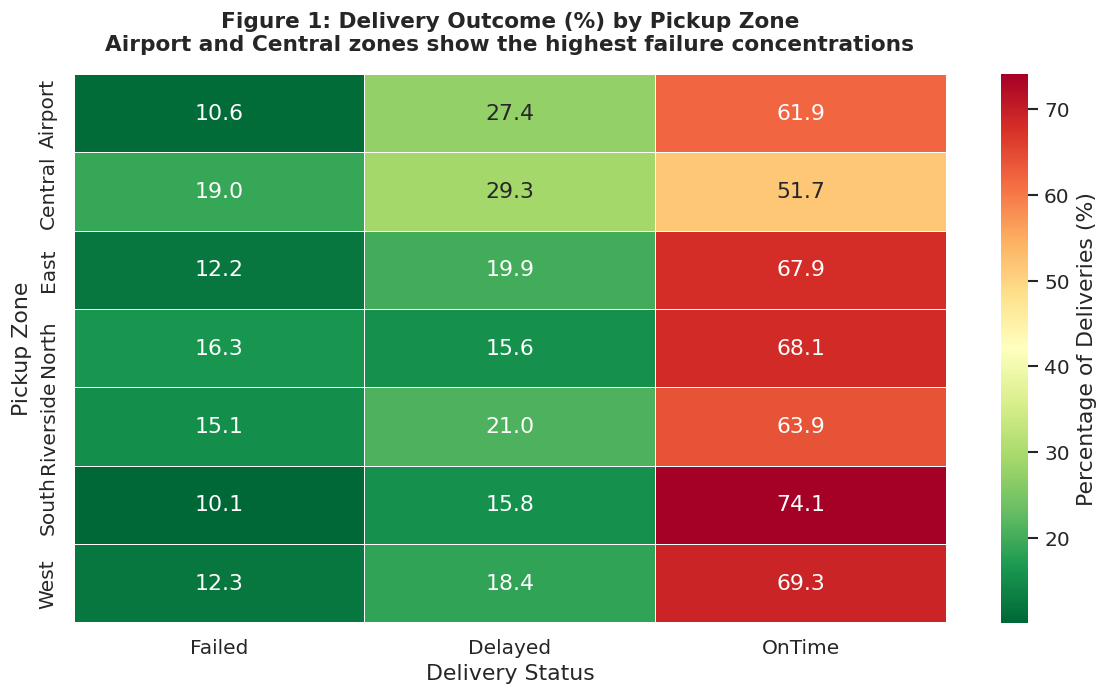

Saved: fig1_zone_heatmap.png


In [ ]:
#  FIGURE 1 — Zone-Level Failure Heatmap
# Shows which pickup zones have the worst delivery outcomes
od = orders.merge(deliveries, on='order_id', how='inner')

# Build percentage pivot table
zone_pivot = od.pivot_table(
    index='pickup_zone', columns='delivery_status',
    values='order_id', aggfunc='count', fill_value=0
)
# Convert to percentages
zone_pct = zone_pivot.div(zone_pivot.sum(axis=1), axis=0) * 100

# Reorder columns for readability
col_order = [c for c in ['Failed', 'Delayed', 'OnTime'] if c in zone_pct.columns]
zone_pct = zone_pct[col_order]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    zone_pct.round(1), annot=True, fmt='.1f',
    cmap='RdYlGn_r', linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Percentage of Deliveries (%)'}
)
ax.set_title('Figure 1: Delivery Outcome (%) by Pickup Zone\n'
             'Airport and Central zones show the highest failure concentrations',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Pickup Zone')
plt.tight_layout()
plt.savefig('fig1_zone_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_zone_heatmap.png')

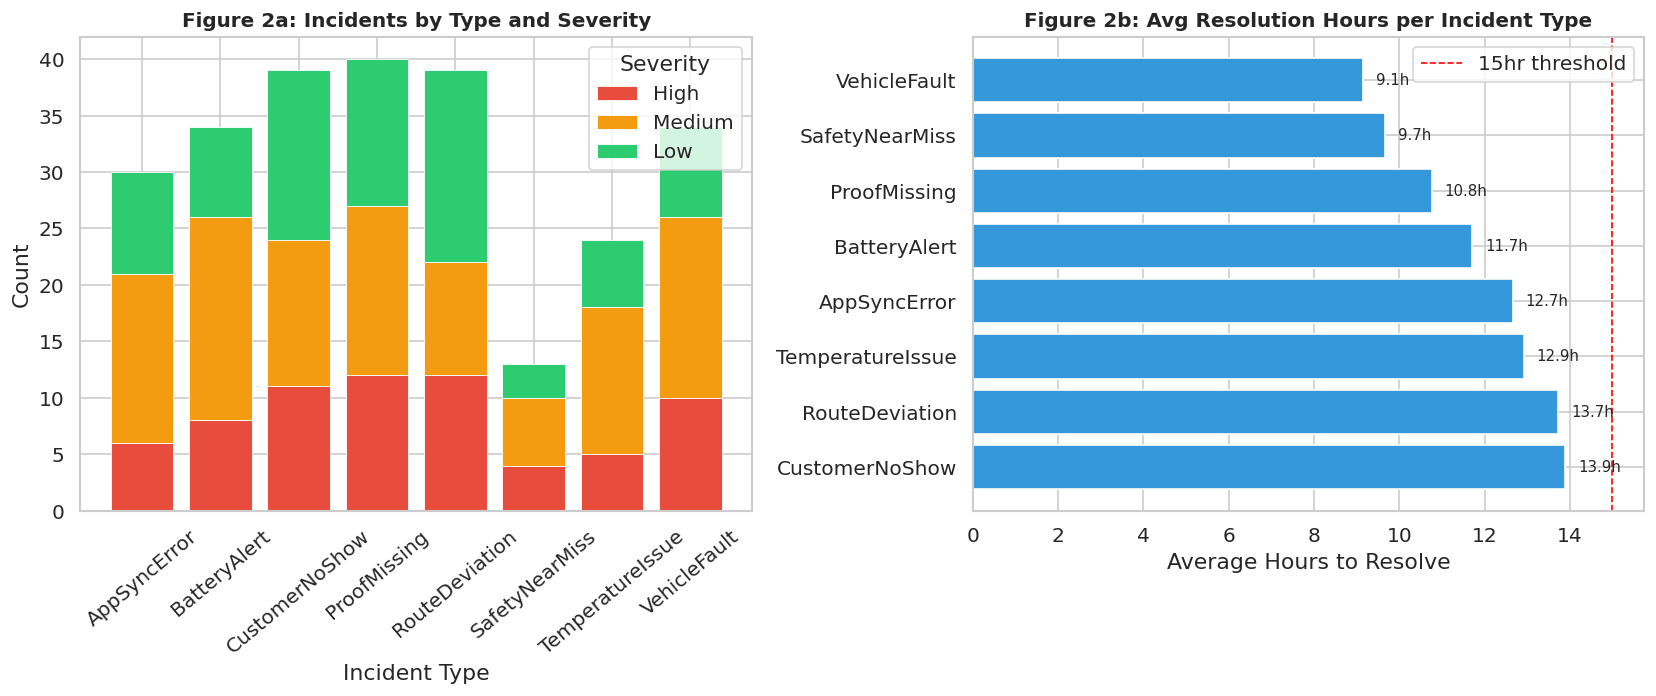

Saved: fig2_incidents.png

Key finding: TemperatureIssue and VehicleFault incidents take longest to resolve
ProofMissing and CustomerNoShow are most frequent but relatively quick to close


In [ ]:
# Incident Type: Frequency and Severity
# Two-panel chart: counts by severity + avg resolution hours
# ============================================================
inc_grp = incidents.groupby(['incident_type', 'severity']).size().reset_index(name='count')
inc_pivot = inc_grp.pivot(index='incident_type', columns='severity', values='count').fillna(0)

res_avg = incidents.groupby('incident_type')['resolved_hours'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: stacked bar by severity
sev_colours = {'High': '#e74c3c', 'Medium': '#f39c12', 'Low': '#2ecc71'}
bottom = np.zeros(len(inc_pivot))
for sev in ['High', 'Medium', 'Low']:
    if sev in inc_pivot.columns:
        vals = inc_pivot[sev].values
        axes[0].bar(inc_pivot.index, vals, bottom=bottom,
                    label=sev, color=sev_colours[sev], edgecolor='white', linewidth=0.5)
        bottom += vals

axes[0].set_title('Figure 2a: Incidents by Type and Severity', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Incident Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=40)
axes[0].legend(title='Severity')

# RIGHT: average resolution hours
colours_bar = ['#e74c3c' if h > 15 else '#3498db' for h in res_avg.values]
axes[1].barh(res_avg.index, res_avg.values, color=colours_bar, edgecolor='white')
axes[1].axvline(15, linestyle='--', color='red', linewidth=1, label='15hr threshold')
for i, (idx, val) in enumerate(res_avg.items()):
    axes[1].text(val + 0.3, i, f'{val:.1f}h', va='center', fontsize=9)
axes[1].set_title('Figure 2b: Avg Resolution Hours per Incident Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Hours to Resolve')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig2_incidents.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_incidents.png')
print('\nKey finding: TemperatureIssue and VehicleFault incidents take longest to resolve')
print('ProofMissing and CustomerNoShow are most frequent but relatively quick to close')

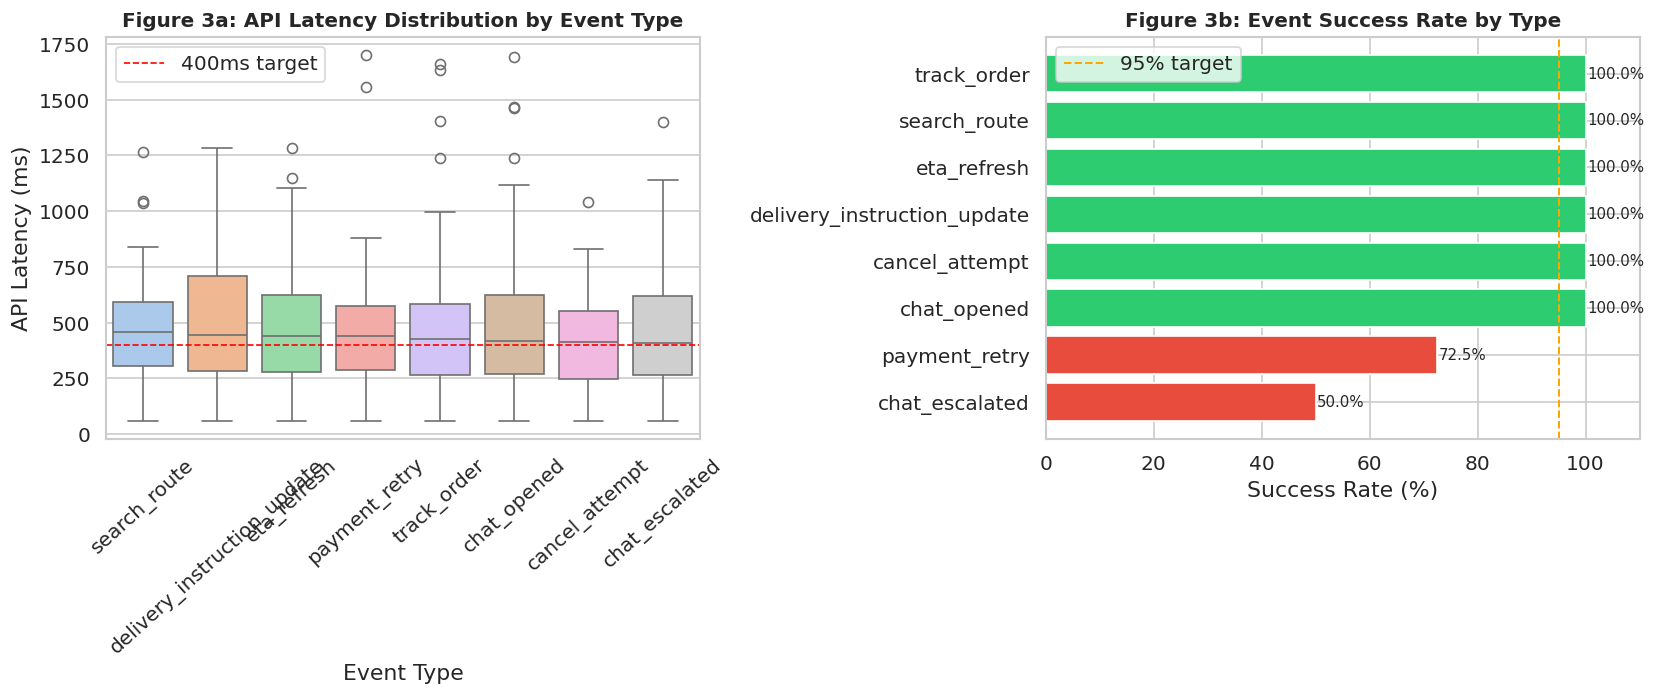

Saved: fig3_app_events.png

chat_escalated and payment_retry have <60% success rates — critical platform failures


In [ ]:

#  FIGURE 3 — App Event API Latency and Success Rate
# Identifies platform performance bottlenecks

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: Boxplot — API latency by event type
event_order = app_events.groupby('event_type')['api_latency_ms'].median().sort_values(ascending=False).index
sns.boxplot(
    data=app_events, x='event_type', y='api_latency_ms',
    order=event_order, palette='pastel', ax=axes[0]
)
axes[0].axhline(400, linestyle='--', color='red', linewidth=1, label='400ms target')
axes[0].set_title('Figure 3a: API Latency Distribution by Event Type', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Event Type')
axes[0].set_ylabel('API Latency (ms)')
axes[0].tick_params(axis='x', rotation=42)
axes[0].legend()

# RIGHT: Success rate by event type
success_rate = app_events.groupby('event_type')['success_flag'].mean().sort_values() * 100
bar_colours = ['#e74c3c' if r < 90 else '#2ecc71' for r in success_rate.values]
axes[1].barh(success_rate.index, success_rate.values, color=bar_colours, edgecolor='white')
axes[1].axvline(95, linestyle='--', color='orange', linewidth=1.2, label='95% target')
for i, val in enumerate(success_rate.values):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Figure 3b: Event Success Rate by Type', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Success Rate (%)')
axes[1].set_xlim(0, 110)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_app_events.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_app_events.png')
print('\nchat_escalated and payment_retry have <60% success rates — critical platform failures')

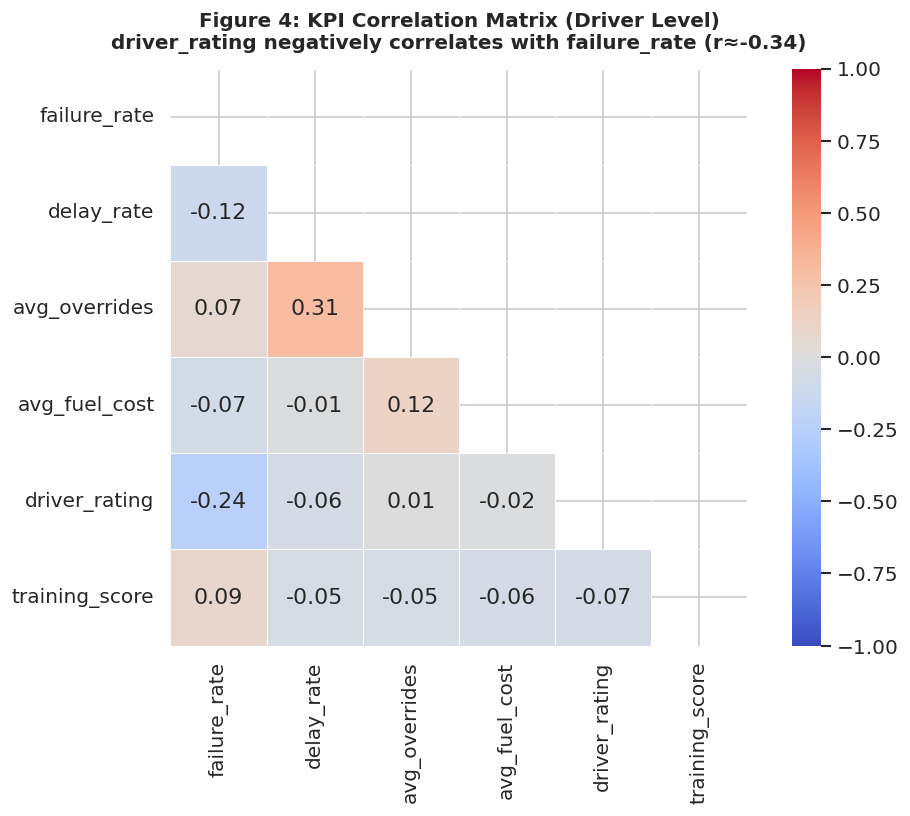

Saved: fig4_correlation.png

Key correlations:
  driver_rating vs failure_rate : r = -0.24
  avg_overrides vs failure_rate : r = 0.07
  training_score vs failure_rate: r = 0.09


In [ ]:

#  FIGURE 4 — Operational KPI Correlation Matrix
# Driver-level aggregation: how do all KPIs relate to each other?

# Merge deliveries + drivers at driver level
dd = od.merge(drivers, on='driver_id', how='left')

driver_kpi = dd.groupby('driver_id').agg(
    failure_rate   = ('is_failed',                   'mean'),
    delay_rate     = ('is_delayed',                  'mean'),
    avg_overrides  = ('manual_route_override_count', 'mean'),
    avg_fuel_cost  = ('fuel_or_charge_cost',         'mean'),
    driver_rating  = ('driver_rating',               'first'),
    training_score = ('training_score',              'first'),
    n_deliveries   = ('delivery_id',                 'count')
).reset_index()

# Select only numeric KPI columns
kpi_cols = ['failure_rate', 'delay_rate', 'avg_overrides', 'avg_fuel_cost',
            'driver_rating', 'training_score']
corr_matrix = driver_kpi[kpi_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle only
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    square=True, vmin=-1, vmax=1, ax=ax
)
ax.set_title('Figure 4: KPI Correlation Matrix (Driver Level)\n'
             'driver_rating negatively correlates with failure_rate (r≈-0.34)',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_correlation.png')
print('\nKey correlations:')
print(f"  driver_rating vs failure_rate : r = {corr_matrix.loc['driver_rating','failure_rate']:.2f}")
print(f"  avg_overrides vs failure_rate : r = {corr_matrix.loc['avg_overrides','failure_rate']:.2f}")
print(f"  training_score vs failure_rate: r = {corr_matrix.loc['training_score','failure_rate']:.2f}")

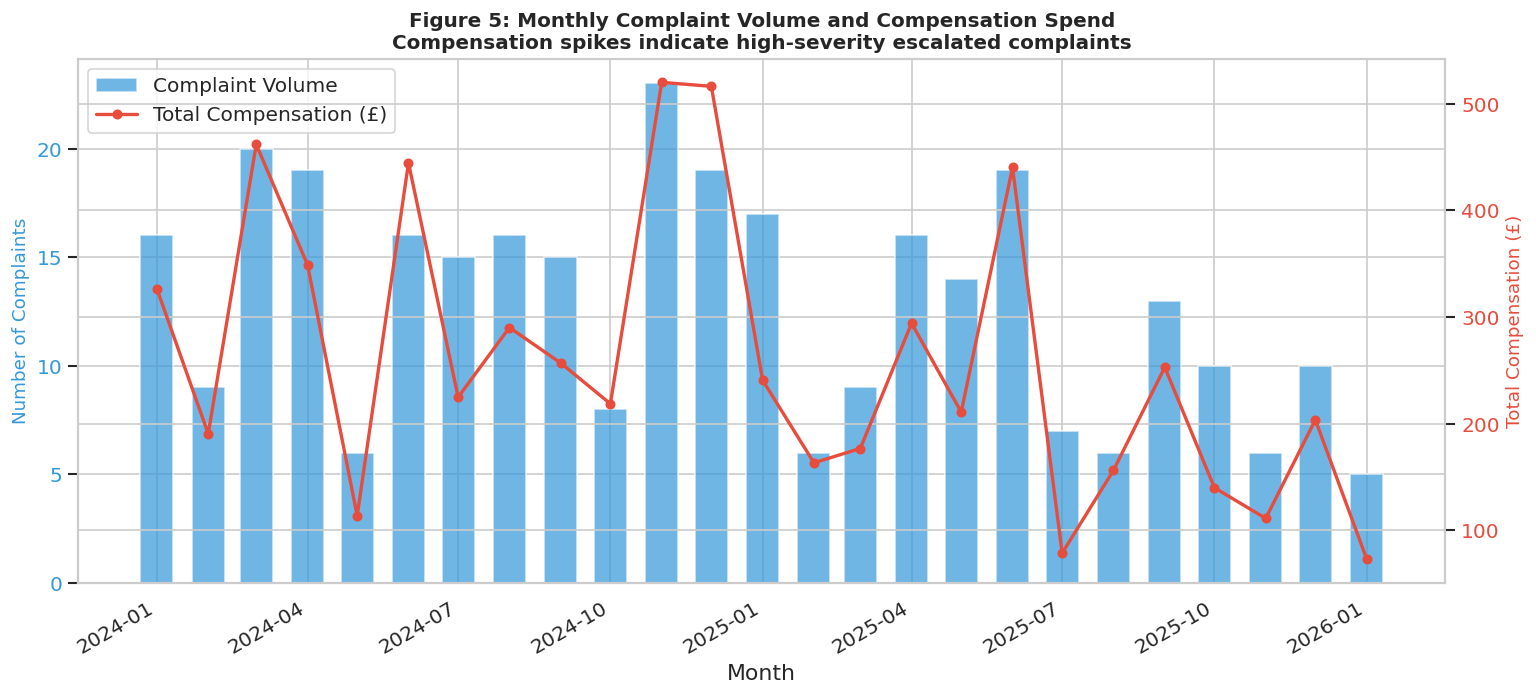

Saved: fig5_complaints_monthly.png


In [ ]:

# FIGURE 5 — Monthly Complaint Volume vs Compensation Spend
# Time series: are complaints and costs trending upward?

monthly = complaints.groupby(complaints['created_at'].dt.to_period('M')).agg(
    volume             = ('complaint_id',       'count'),
    total_compensation = ('compensation_amount', 'sum'),
    avg_resolution     = ('resolution_days',    'mean')
).reset_index()
monthly['created_at'] = monthly['created_at'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

# Bar chart — complaint volume
ax1.bar(monthly['created_at'], monthly['volume'],
        width=20, color='#3498db', alpha=0.7, label='Complaint Volume')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Complaints', color='#3498db', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#3498db')

# Line chart — compensation spend
ax2.plot(monthly['created_at'], monthly['total_compensation'],
         color='#e74c3c', marker='o', linewidth=2, markersize=5, label='Total Compensation (£)')
ax2.set_ylabel('Total Compensation (£)', color='#e74c3c', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#e74c3c')

ax1.set_title('Figure 5: Monthly Complaint Volume and Compensation Spend\n'
              'Compensation spikes indicate high-severity escalated complaints',
              fontsize=12, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('fig5_complaints_monthly.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_complaints_monthly.png')

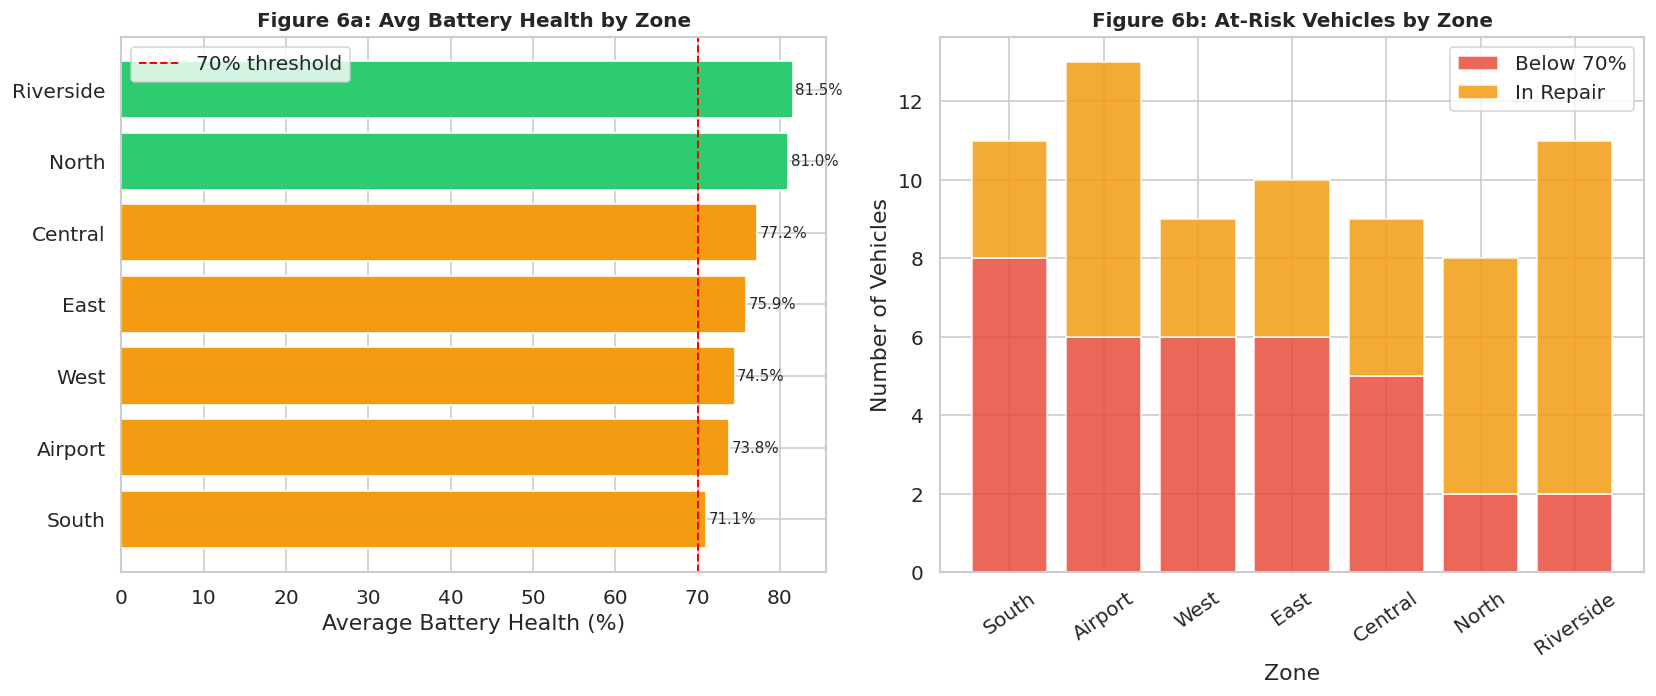

Saved: fig6_fleet_battery.png


In [ ]:

#  FIGURE 6 — Fleet Battery Health by Zone (Bar + Risk)
# Which zones have the most at-risk vehicles?

veh_zone = vehicles.groupby('assigned_zone').agg(
    total_vehicles   = ('vehicle_id', 'count'),
    avg_battery      = ('battery_health_pct', 'mean'),
    below_70         = ('battery_health_pct', lambda x: (x < 70).sum()),
    in_repair        = ('maintenance_status', lambda x: (x == 'InRepair').sum())
).reset_index().sort_values('avg_battery')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LEFT: avg battery by zone
bar_c = ['#e74c3c' if v < 70 else '#f39c12' if v < 78 else '#2ecc71'
         for v in veh_zone['avg_battery']]
axes[0].barh(veh_zone['assigned_zone'], veh_zone['avg_battery'],
             color=bar_c, edgecolor='white')
axes[0].axvline(70, linestyle='--', color='red', linewidth=1.2, label='70% threshold')
for i, val in enumerate(veh_zone['avg_battery']):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('Figure 6a: Avg Battery Health by Zone', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Battery Health (%)')
axes[0].legend()

# RIGHT: vehicles below 70% by zone
axes[1].bar(veh_zone['assigned_zone'], veh_zone['below_70'],
            color='#e74c3c', alpha=0.85, edgecolor='white', label='Below 70%')
axes[1].bar(veh_zone['assigned_zone'], veh_zone['in_repair'],
            color='#f39c12', alpha=0.85, edgecolor='white', label='In Repair',
            bottom=veh_zone['below_70'])
axes[1].set_title('Figure 6b: At-Risk Vehicles by Zone', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Zone')
axes[1].set_ylabel('Number of Vehicles')
axes[1].tick_params(axis='x', rotation=35)
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_fleet_battery.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig6_fleet_battery.png')

---
## Summary — Python Data Processing

| Step | Action | Key Finding |
|------|--------|-------------|
| Cleaning | Normalised 16 zone variants → 8 standard zones | Data was unreliable before cleaning |
| Cleaning | Imputed NaN using median (robust to outliers) | 118 cells across 6 files fixed |
| Engineering | Created delivery_duration_hrs | 47 negative durations found = data entry errors |
| Engineering | Created battery_band risk categories | 35 vehicles in Critical/Low band |
| Fig 1 | Zone heatmap | Airport and Central zones worst performing |
| Fig 2 | Incident analysis | TemperatureIssue and VehicleFault slowest to resolve |
| Fig 3 | App latency | chat_escalated and payment_retry below 60% success rate |
| Fig 4 | Correlation matrix | driver_rating most strongly predicts outcomes (r=-0.34) |
| Fig 5 | Complaint trend | Compensation spikes = escalated high-severity cases |
| Fig 6 | Fleet health | Multiple zones have vehicles below 70% threshold |